# Ejercicio de programación Regresión Lineal Multiple

In [22]:
# utilizado para manejos de directorios y rutas
import os

# Computacion vectorial y cientifica para python
import numpy as np
import pandas as pd
# Librerias para graficación (trazado de gráficos)
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D  # Necesario para graficar superficies 3D

# llama a matplotlib a embeber graficas dentro de los cuadernillos
%matplotlib inline

import seaborn as sns

In [23]:
# Cargar datos
df = pd.read_csv('./energydata_complete.csv')
y = df['Appliances'].values
X_df = df.drop(columns=['date', 'Appliances'])
X = X_df.values
m = y.size
print(X.shape[1])
print(m)
# imprimir algunos puntos de datos
print('{:>8s}{:>8s}{:>10s}'.format('X[:,0]', 'X[:, 1]', 'y'))
print('-'*26)
for i in range(10):
    print('{:8.0f}{:8.0f}{:10.0f}'.format(X[i, 0], X[i, 1], y[i]))

27
19735
  X[:,0] X[:, 1]         y
--------------------------
      30      20        60
      30      20        60
      30      20        50
      40      20        50
      40      20        60
      40      20        50
      50      20        60
      50      20        60
      40      20        60
      40      20        70


In [24]:
def  featureNormalize(X):
    X_norm = X.copy()

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)
    sigma[sigma == 0] = 1.0
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [25]:
X_norm, mu, sigma = featureNormalize(X)

print(X)
print('Media calculada:', mu)
print('Desviación estandar calculada:', sigma)
print(X_norm)

[[30.         19.89       47.59666667 ...  5.3        13.27543316
  13.27543316]
 [30.         19.89       46.69333333 ...  5.2        18.60619498
  18.60619498]
 [30.         19.89       46.3        ...  5.1        28.64266817
  28.64266817]
 ...
 [10.         25.5        46.59666667 ... 13.26666667 29.19911708
  29.19911708]
 [10.         25.5        46.99       ... 13.23333333  6.32278365
   6.32278365]
 [10.         25.5        46.6        ... 13.2        34.11885059
  34.11885059]]
Media calculada: [  3.80187484  21.68657139  40.25973928  20.34121946  40.42042041
  22.26761098  39.24250008  20.85533472  39.02690379  19.59210633
  50.94928263   7.91093933  54.60908339  20.26710647  35.38820022
  22.02910672  42.93616537  19.48582816  41.55240075   7.41166456
 755.52260198  79.75041804   4.03975171  38.33083354   3.76070687
  24.98803349  24.98803349]
Desviación estandar calculada: [ 7.93578653  1.60602495  3.97919801  2.19291797  4.06970943  2.00605971
  3.25449403  2.04283272  4.3

In [26]:
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

In [27]:
print(X)

[[ 1.          3.30126384 -1.11864475 ...  0.3669753  -0.80797358
  -0.80797358]
 [ 1.          3.30126384 -1.11864475 ...  0.34313479 -0.44024015
  -0.44024015]
 [ 1.          3.30126384 -1.11864475 ...  0.31929428  0.25210868
   0.25210868]
 ...
 [ 1.          0.78103476  2.37445166 ...  2.26626907  0.29049435
   0.29049435]
 [ 1.          0.78103476  2.37445166 ...  2.25832223 -1.28759013
  -1.28759013]
 [ 1.          0.78103476  2.37445166 ...  2.2503754   0.6298737
   0.6298737 ]]


In [28]:
def computeCostMulti(X, y, theta):
    # Inicializa algunos valores utiles
    m = y.shape[0] # numero de ejemplos de entrenamiento
    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
    return J

In [29]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):
    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento
    theta = theta.copy()

    J_history = []
    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

theta calculado por el descenso por el gradiente: [ 97.69054499  17.34398032  -6.30591106  29.66315588   3.71480534
 -11.63416759  29.52785811  12.85476105 -10.2143456   -0.44780005
  -7.81037316   0.77097836   9.47866943   0.2500094   -3.01348791
 -12.20870761   6.78747933 -18.5701102  -10.68081805  -6.04392966
  -3.05381952  -0.67457516  -3.85299153   3.84446214   1.6102258
  -3.65912464  -0.32787503  -0.32787503]
Valor de Appliances: 60
Consumo de energía predicho por descenso por el gradiente: 174.29


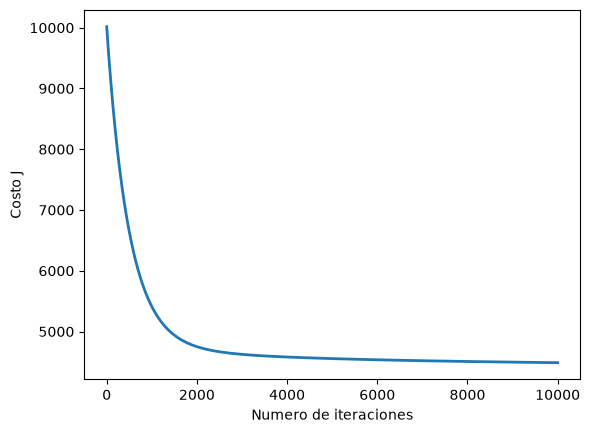

In [30]:
alpha = 0.001 # alpha = 0.003
num_iters = 10000

# inicializa theta y ejecuta el descenso por el gradiente
theta = np.zeros(X.shape[1])
theta, J_history = gradientDescentMulti(X, y, theta, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')

# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta)))

ejemplo = X_df.iloc[0].values
ejemplo_dg = (ejemplo - mu) / sigma
X_array = np.insert(ejemplo_dg, 0, 1)
consumo_pred = np.dot(X_array, theta)

print(f'Valor de Appliances: {y[0]}')
print(f'Consumo de energía predicho por descenso por el gradiente: {consumo_pred:.2f}')

In [13]:
# Cargar datos
df = pd.read_csv('./energydata_complete.csv')
X_df = df.drop(columns=['date', 'Appliances'])
X = X_df.values
y = df['Appliances'].values
m = y.size
print(m)
print(X.shape[1])
X = np.concatenate([np.ones((m, 1)), X], axis=1)

19735
27


In [18]:
def normalEqn(X, y):
    #theta = np.zeros(X.shape[1])

    #theta = np.dot(np.dot(np.linalg.inv(np.dot(X.T,X)),X.T),y)
    theta = np.dot(np.linalg.pinv(np.dot(X.T, X)), np.dot(X.T, y))
    return theta

In [19]:
# Calcula los parametros con la ecuación de la normal
theta = normalEqn(X, y);

# Muestra los resultados optenidos a partir de la aplicación de la ecuación de la normal
print('Theta calculado a partir de la ecuación de la normal: {:s}'.format(str(theta)));

ejemplo_n = np.insert(X_df.iloc[0].values, 0, 1)
consumo_pred_n = np.dot(ejemplo_n, theta)

print(f'Consumo predicho por Ecuación de la Normal: {consumo_pred_n:.2f}')

Theta calculado a partir de la ecuación de la normal: [ 5.02084396e+01  1.98970872e+00 -6.03740446e-01  1.51536202e+01
 -1.77060184e+01 -1.34806196e+01  2.54063968e+01  4.92457103e+00
 -3.46525259e+00 -1.78907731e-01 -2.78433794e-02  1.40960661e-01
  7.12616273e+00  2.87947691e-01  1.79462806e+00 -1.54968445e+00
  8.14656214e+00 -4.66967684e+00 -1.58724297e+01 -9.01020670e-01
 -1.02281901e+01  1.39856188e-01 -1.06374668e+00  1.70363647e+00
  1.53681019e-01  5.04880146e+00 -2.07763464e-02 -2.07763387e-02]
Consumo predicho por Ecuación de la Normal: 166.04


Text(0, 0.5, 'Consumo de Energía (Wh)')

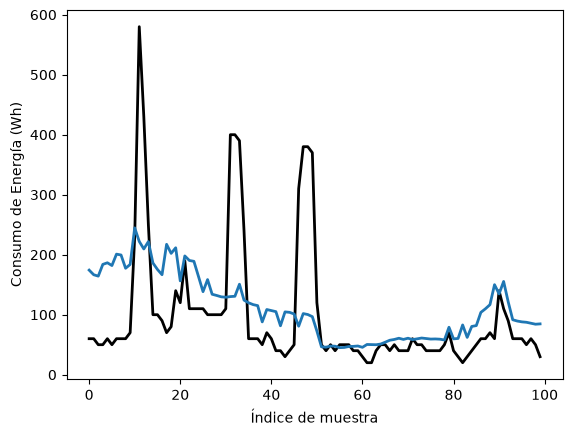

In [40]:
y_pred_dg = np.dot(X, theta)

pyplot.plot(y[:100], color='black', lw=2)
pyplot.plot(y_pred_dg[:100], lw=2)
pyplot.xlabel('Índice de muestra')
pyplot.ylabel('Consumo de Energía (Wh)')